# Visualize comparisons

This notebook visualizes some comparisons the two different algorithms of Musclemap that can segment thighs

In [1]:
import sys
import os
import matplotlib as mpl
import matplotlib.pyplot as plt 
import numpy as np
import pandas as pd

In [2]:
sys.path.append(os.path.abspath("../../src/dissector"))

In [3]:
from evaluation import single_row_viz
from evaluation import radarplot_single_dataset

## here we do examples on the gracilis

In [4]:
thigh_left_grac_dataset = pd.read_csv('../MuscleMap_results_thigh/df_l_gracilis_thigh.csv')
body_left_grac_dataset = pd.read_csv('../MuscleMap_results_WB/df_l_gracilis.csv')

In [5]:
thigh_left_sart_dataset = pd.read_csv('../MuscleMap_results_thigh/df_l_sart_thigh.csv')
body_left_sart_dataset = pd.read_csv('../MuscleMap_results_WB/df_l_sart.csv')

In [6]:
thigh_left_grac_dataset.head(3)

,Unnamed: 0,image,pred_label,L_gracilis_lower_dice:,L_gracilis_lower_Hausdorff:,L_gracilis_jaccard,L_gracilis_volume_similarity,L_gracilis_falseNegative,L_gracilis_falsePostivie
0,0,HV001_1/SegmentationMasks/combined_gt_stack1.mha,HV001_1_FATFRACTION_stack1_dseg.nii.gz,0.764219,7.000000,0.618410,-1.440162,0.241125,0.000108
1,1,HV001_1/SegmentationMasks/combined_gt_stack2.mha,HV001_1_FATFRACTION_stack2_dseg.nii.gz,0.818813,8.124038,0.693212,-1.440162,0.194773,0.000123
2,2,HV001_2/SegmentationMasks/combined_gt_stack1.mha,HV001_2_FATFRACTION_stack1_dseg.nii.gz,0.782853,5.000000,0.643187,-1.440162,0.243911,0.000089


In [7]:
len(thigh_left_grac_dataset)

54

## we know dice will be between 0 to 1, as will Jaccard, but not false positive and false negatives
### so let's visualize them in a cross in a circle or square

There is the caveat that false negative and positive should be as low as possible, while DIce and Jaccaard should be as high as possible. Therefore we will use 1 - false negative and 1 - false positive to keep a simple visual where bigger is better

#### bigger is better in our radarplot visualization

In [8]:
thigh_left_grac_dataset['one_minus_falseNegative'] = 1 - thigh_left_grac_dataset['L_gracilis_falseNegative'] 
thigh_left_grac_dataset['one_minus_falsePositive'] = 1 - thigh_left_grac_dataset['L_gracilis_falsePostivie'] 

In [9]:
thigh_left_sart_dataset['one_minus_falseNegative'] = 1 - thigh_left_sart_dataset['L_sartor_falseNegative'] 
thigh_left_sart_dataset['one_minus_falsePositive'] = 1 - thigh_left_sart_dataset['L_sartor_falsePostivie'] 

In [10]:
body_left_sart_dataset['one_minus_falseNegative'] = 1 - body_left_sart_dataset['L_sartor_falseNegative'] 
body_left_sart_dataset['one_minus_falsePositive'] = 1 - body_left_sart_dataset['L_sartor_falsePostivie'] 

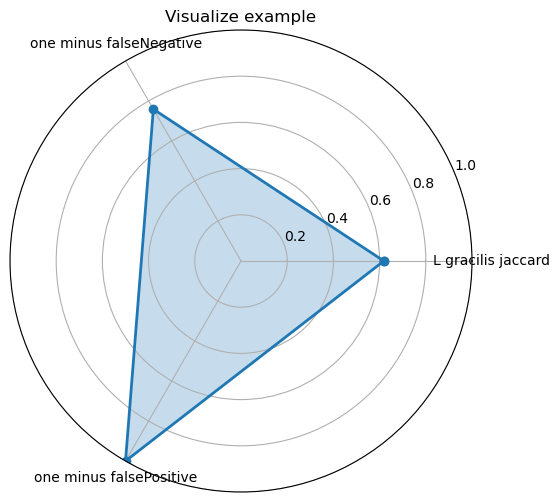

In [11]:
single_row_viz(["L_gracilis_jaccard","one_minus_falseNegative","one_minus_falsePositive"], thigh_left_grac_dataset, 0, "Visualize example")

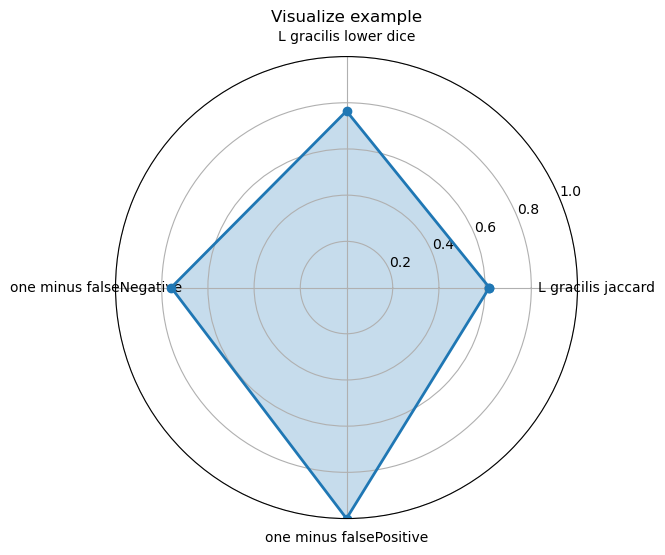

In [12]:
single_row_viz(["L_gracilis_jaccard","L_gracilis_lower_dice:","one_minus_falseNegative","one_minus_falsePositive"], thigh_left_grac_dataset, 0, "Visualize example")

In [13]:
# def radarplot_single_datasetH(metrics, dataset, title, labels=metrics):
    
#     # Create angles
#     num_metrics = len(metrics)
#     angles = np.linspace(0, 2*np.pi, num_metrics, endpoint=False)
#     angles = np.append(angles, angles[0])
    
#     # Create figure + polar axis
#     fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
    
#     # Plot multiple samples
#     for i in range(len(dataset)):
#         row = dataset.iloc[i]
#         values = row[metrics].values.astype(float)
#         values = np.append(values, values[0])
#         ax.plot(angles, values, color="blue", alpha=0.4)
    
#     # Labels
#     ax.set_xticks(angles[:-1])
#     ax.set_xticklabels(labels)
#     ax.set_ylim(0, 1)
    
#     plt.title(title)
#     plt.show()

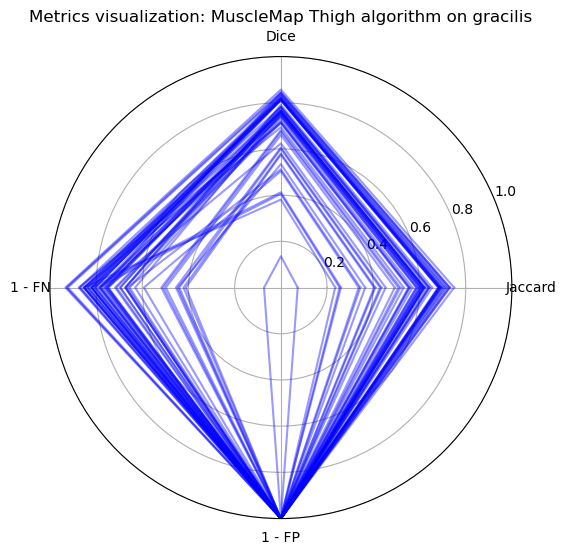

In [17]:
radarplot_single_dataset(
    ["L_gracilis_jaccard","L_gracilis_lower_dice:","one_minus_falseNegative","one_minus_falsePositive"],
    thigh_left_grac_dataset,
    "Metrics visualization: MuscleMap Thigh algorithm on gracilis",
    ["Jaccard","Dice","1 - FN","1 - FP"]
        )

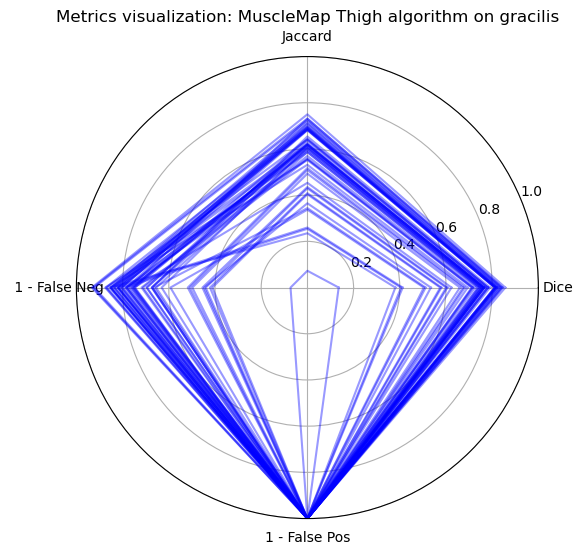

## What does this tell us? 

With the thigh algorithm, we never get false positives...the segmentation is always inside the ground truth. This is an important note...let's compare to the whole body algorithm

In [ ]:
# src\dissector\evaluation.py:153:14: PD011 Use `.to_numpy()` instead of `.values`
# src\dissector\evaluation.py:163:53: C408 Unnecessary `dict()` call (rewrite as a literal)
# src\dissector\evaluation.py:187:18: E711 Comparison to `None` should be `cond is None`
# src\dissector\evaluation.py:195:5: RUF059 Unpacked variable `fig` is never used
# src\dissector\evaluation.py:195:54: C408 Unnecessary `dict()` call (rewrite as a literal)
# src\dissector\evaluation.py:200:18: PD011 Use `.to_numpy()` instead of `.values`
# Found 6 errors.
# No fixes available (4 hidden fixes can be enabled with the `--unsafe-fixes` option).
# (ultraseg) 

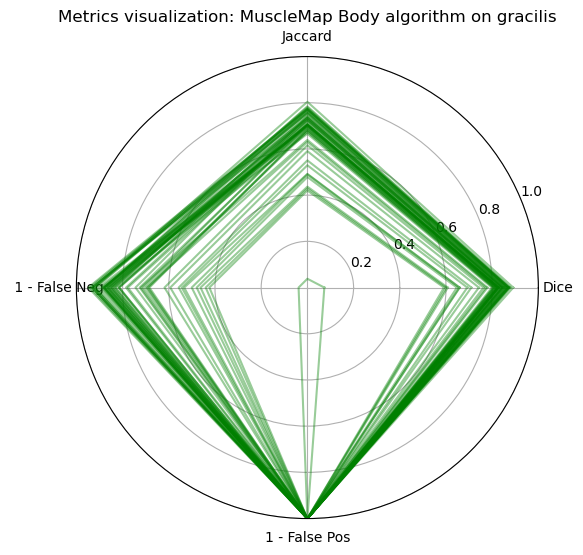

In [18]:
body_left_grac_dataset['one_minus_falseNegative'] = 1 - body_left_grac_dataset['L_gracilis_falseNegative'] 
body_left_grac_dataset['one_minus_falsePositive'] = 1 - body_left_grac_dataset['L_gracilis_falsePostivie']
metrics = [
    "L_gracilis_lower_dice:",
    "L_gracilis_jaccard",
    "one_minus_falseNegative",
    "one_minus_falsePositive"
]

# Create angles
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
angles = np.append(angles, angles[0])

# Create figure + polar axis
fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

# Plot multiple samples
for i in range(54):
    row = body_left_grac_dataset.iloc[i]
    values = row[metrics].values.astype(float)
    values = np.append(values, values[0])
    ax.plot(angles, values, color="green", alpha=0.4)

# Labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Dice", "Jaccard", " 1 - False Neg", "1 - False Pos"])
ax.set_ylim(0, 1)

plt.title("Metrics visualization: MuscleMap Body algorithm on gracilis")
plt.show()

In [ ]:

mpl.rcParams.update({
    # --- CRITICAL: makes SVG self-contained ---
    "svg.fonttype": "none",        # keep text as text (NOT paths)
    "text.usetex": False,          # NEVER use LaTeX rendering
    "font.family": "DejaVu Sans",  # safe default font

    # --- avoids weird Inkscape flow elements ---
    "path.simplify": True,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})
metrics = [
    "L_gracilis_lower_dice:",
    "L_gracilis_jaccard",
    "one_minus_falseNegative",
    "one_minus_falsePositive"
]

# Angles (shared)
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
angles = np.append(angles, angles[0])

# Create ONE figure with TWO polar subplots
fig, axes = plt.subplots(1, 2, figsize=(12,6), subplot_kw=dict(polar=True))

# ---- LEFT: thigh ----
ax = axes[0]
for i in range(54):
    row = thigh_left_grac_dataset.iloc[i]
    values = row[metrics].values.astype(float)
    values = np.append(values, values[0])
    ax.plot(angles, values, color="blue", alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Dice", "Jaccard", "1 - FN", "1 - FP"])
for label in ax.get_xticklabels():
    label.set_fontsize(10)
    label.set_y(label.get_position()[1] - 0.08) 
ax.set_ylim(0, 1)
ax.set_title("Muscle Map Thigh algorithm for gracilis")

# ---- RIGHT: body ----
ax = axes[1]
for i in range(54):
    row = body_left_grac_dataset.iloc[i]
    values = row[metrics].values.astype(float)
    values = np.append(values, values[0])
    ax.plot(angles, values, color="green", alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Dice", "Jaccard", "1 - FN", "1 - FP"])
for label in ax.get_xticklabels():
    label.set_fontsize(10)
    label.set_y(label.get_position()[1] - 0.08) 
ax.set_ylim(0, 1)
ax.set_title( "Muscle Map Body algorithm for gracilis")

plt.tight_layout()
plt.rcParams['svg.fonttype'] = 'none'
plt.savefig("gracilis_comparison4.png", dpi=300, bbox_inches="tight", transparent=False)
plt.show()

In [ ]:
thigh_left_sart_dataset.head(2)

In [ ]:
metrics = [
    "L_sartor_lower_dice:",
    "L_sartor_jaccard",
    "one_minus_falseNegative",
    "one_minus_falsePositive"
]

# Angles (shared)
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False)
angles = np.append(angles, angles[0])

# Create ONE figure with TWO polar subplots
fig, axes = plt.subplots(1, 2, figsize=(10,5), subplot_kw=dict(polar=True))

# ---- LEFT: thigh ----
ax = axes[0]
for i in range(54):
    row = thigh_left_sart_dataset.iloc[i]
    values = row[metrics].values.astype(float)
    values = np.append(values, values[0])
    ax.plot(angles, values, color="blue", alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Dice", "Jaccard", "1 - FN", "1 - FP"])
for label in ax.get_xticklabels():
    label.set_fontsize(10)
    label.set_y(label.get_position()[1] - 0.08) 
ax.set_ylim(0, 1)
ax.set_title("Muscle Map Thigh algorithm for Sartorius")

# ---- RIGHT: body ----
ax = axes[1]
for i in range(54):
    row = body_left_sart_dataset.iloc[i]
    values = row[metrics].values.astype(float)
    values = np.append(values, values[0])
    ax.plot(angles, values, color="green", alpha=0.2)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(["Dice", "Jaccard", "1 - FN", "1 - FP"], rotation=20)
for label in ax.get_xticklabels():
    label.set_fontsize(10)
    label.set_y(label.get_position()[1] - 0.08) 
ax.set_ylim(0, 1)
ax.set_title( "Muscle Map Body algorithm for Sartorius")



plt.tight_layout()
plt.savefig("sartorius_comparison.png", dpi=300, bbox_inches="tight")
#plt.savefig("sartorius_comparison.svg", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
fig, axes = plt.subplots(3, 3, subplot_kw=dict(polar=True), figsize=(10,10))

for i, ax in enumerate(axes.flat):
    if i >= len(thigh_left_grac_dataset):
        break
        
    row = thigh_left_grac_dataset.iloc[i]
    values = row[metrics].values.astype(float)
    values = np.append(values, values[0])
    
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.2)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f"{i}")

plt.tight_layout()
plt.show()